Batch 1/50, MSE Error: 1947.385824
Batch 2/50, MSE Error: 1963.232780
Batch 3/50, MSE Error: 1901.448733
Batch 4/50, MSE Error: 1801.034611
Batch 5/50, MSE Error: 1650.577500
Batch 6/50, MSE Error: 1550.470356
Batch 7/50, MSE Error: 1328.357350
Batch 8/50, MSE Error: 1541.517228
Batch 9/50, MSE Error: 1451.819287
Batch 10/50, MSE Error: 1079.537702
Batch 11/50, MSE Error: 1041.531375
Batch 12/50, MSE Error: 1183.979460
Batch 13/50, MSE Error: 880.765339
Batch 14/50, MSE Error: 803.493063
Batch 15/50, MSE Error: 604.388899
Batch 16/50, MSE Error: 509.972089
Batch 17/50, MSE Error: 468.480417
Batch 18/50, MSE Error: 378.139859
Batch 19/50, MSE Error: 281.557608
Batch 20/50, MSE Error: 250.157622
Batch 21/50, MSE Error: 149.447283
Batch 22/50, MSE Error: 123.909226
Batch 23/50, MSE Error: 116.016985
Batch 24/50, MSE Error: 100.944562
Batch 25/50, MSE Error: 90.640782
Batch 26/50, MSE Error: 84.768299
Batch 27/50, MSE Error: 84.538676
Batch 28/50, MSE Error: 90.093239
Batch 29/50, MSE Erro

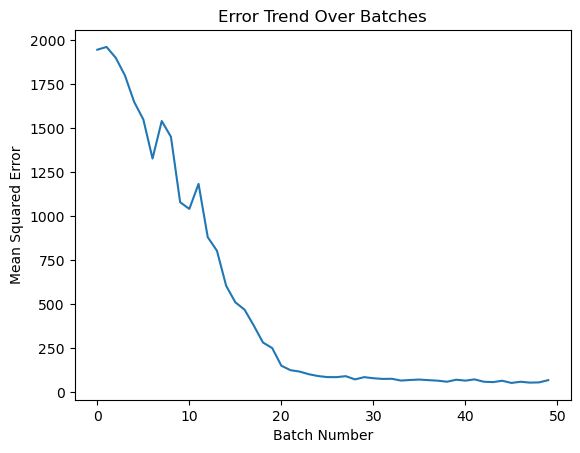

Overall MSE for Neural Network Predictions on Test Data: 76.496622


In [11]:
import numpy as np
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import shap
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Generate a regression dataset
X, y = make_regression(n_samples=10000, n_features=10, noise=0.5, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train a RandomForestRegressor
regressor = RandomForestRegressor(n_estimators=100, random_state=42)
regressor.fit(X_train, y_train)

# Initialize SHAP TreeExplainer
tree_explainer = shap.TreeExplainer(regressor)

# Step 2: Define a Simple Neural Network
class SimpleNeuralNet(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(SimpleNeuralNet, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, output_dim)
        )
        self._initialize_weights()

    def forward(self, x):
        return self.fc(x)

    def _initialize_weights(self):
        # Initialize weights for stability
        for layer in self.fc:
            if isinstance(layer, nn.Linear):
                nn.init.kaiming_normal_(layer.weight)
                if layer.bias is not None:
                    nn.init.zeros_(layer.bias)

# Initialize the neural network, optimizer, and loss function
input_dim = X_train.shape[1]
output_dim = X_train.shape[1]  # SHAP values for each feature
model = SimpleNeuralNet(input_dim, output_dim)
optimizer = optim.Adam(model.parameters(), lr=0.005)  # Slightly higher initial learning rate
criterion = nn.MSELoss()

# Step 3: Iterative Training and Error Tracking for Batches
batch_size = 50
num_batches = 50
errors = []  # Track MSE for each batch

for batch_idx in range(num_batches):
    # Select a random batch
    batch_indices = np.random.choice(X_train.shape[0], batch_size, replace=False)
    X_batch = X_train[batch_indices]

    # Ground truth SHAP values using TreeExplainer
    shap_values_tree = np.array(tree_explainer.shap_values(X_batch))  # Shape: [batch_size, n_features]

    # Convert to tensors
    X_batch_tensor = torch.tensor(X_batch, dtype=torch.float32)
    shap_values_tree_tensor = torch.tensor(shap_values_tree, dtype=torch.float32)

    # Predict SHAP values using the Neural Network
    shap_values_nn = model(X_batch_tensor).detach().numpy()  # Shape: [batch_size, n_features]

    # Calculate error for the batch
    batch_mse = mean_squared_error(shap_values_tree.flatten(), shap_values_nn.flatten())
    errors.append(batch_mse)

    # Print batch error
    print(f"Batch {batch_idx + 1}/{num_batches}, MSE Error: {batch_mse:.6f}")

    # Update the neural network
    for epoch in range(5):  # Fewer epochs for stability
        optimizer.zero_grad()
        predictions = model(X_batch_tensor)
        loss = criterion(predictions, shap_values_tree_tensor)
        loss.backward()
        optimizer.step()

    # Decay learning rate slightly after each batch
    for g in optimizer.param_groups:
        g['lr'] *= 0.99  # Simple learning rate decay

# Step 4: Plot the error trend
plt.plot(errors)
plt.xlabel("Batch Number")
plt.ylabel("Mean Squared Error")
plt.title("Error Trend Over Batches")
plt.show()

# Step 5: Generate Predictions and Calculate Errors for Test Data
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

# TreeExplainer predictions
shap_values_tree = np.array(tree_explainer.shap_values(X_test))  # Shape: [n_test_samples, n_features]

# Neural network predictions
shap_values_nn = model(X_test_tensor).detach().numpy()  # Shape: [n_test_samples, n_features]

# Combine Predictions into a DataFrame with Errors
results = []

for i in range(X_test.shape[0]):
    for j in range(X_test.shape[1]):  # Iterate over each feature's SHAP value
        error = abs(shap_values_tree[i][j] - shap_values_nn[i][j])  # Absolute error
        results.append({
            "Sample": i,
            "Feature": f"Feature_{j + 1}",
            "TreeExplainer": shap_values_tree[i][j],
            "NeuralNetwork": shap_values_nn[i][j],
            "Error": error
        })

results_df = pd.DataFrame(results)

# Step 6: Save to a CSV File
results_df.to_csv("shap_predictions_with_errors.csv", index=False)

# Display the first few rows
# print(results_df.head(20))

# Step 7: Calculate and Print Overall MSE for Test Data
overall_mse = mean_squared_error(shap_values_tree.flatten(), shap_values_nn.flatten())
print(f"Overall MSE for Neural Network Predictions on Test Data: {overall_mse:.6f}")
